In [11]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [12]:
#Load and explore data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
print(f"Shape: {fraud_df.shape}")
print(f"Fraud rate: {fraud_df['class'].mean()*100:.4f}%")
fraud_df.head()

Shape: (151112, 11)
Fraud rate: 9.3646%


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [13]:
#Data types and missing values
print("Data Types:")
print(fraud_df.dtypes)
print("\nMissing values:")
print(fraud_df.isnull().sum())
print(f"\nDuplicates: {fraud_df.duplicated().sum()}")

Data Types:
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

Missing values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Duplicates: 0


In [14]:
# Convert time columns
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
fraud_df = fraud_df.drop_duplicates()
print(f"Cleaned shape: {fraud_df.shape}")

Cleaned shape: (151112, 11)


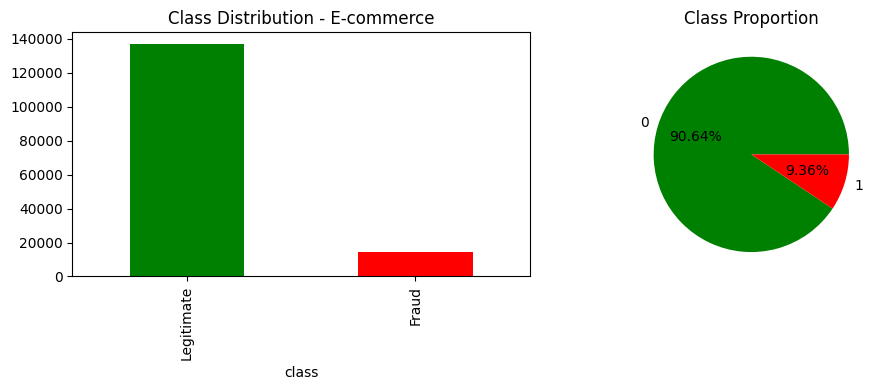

In [15]:
# Class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fraud_df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution - E-commerce')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
fraud_df['class'].value_counts().plot(kind='pie', autopct='%1.2f%%', ax=axes[1], colors=['green', 'red'])
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.savefig('../reports/fraud_imbalance_ecommerce.png', dpi=100)
plt.show()

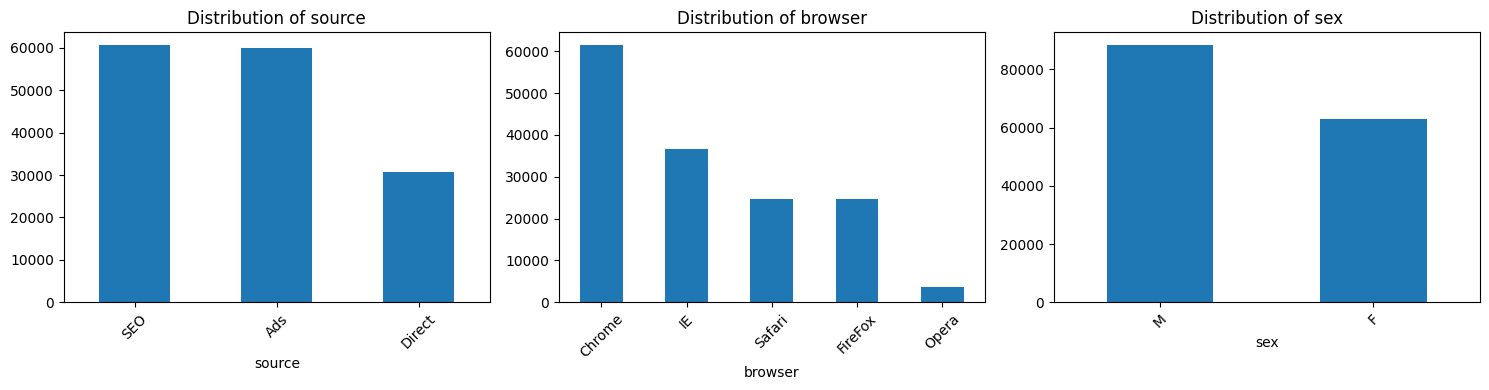

In [16]:
#Categorical features analysis
categorical_cols = ['source', 'browser', 'sex']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(categorical_cols):
    fraud_df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=100)
plt.show()

In [17]:
#Numerical features analysis
print("Purchase Value Statistics:")
print(fraud_df['purchase_value'].describe())
print("\nPurchase Value by Class:")
print(fraud_df.groupby('class')['purchase_value'].describe())

Purchase Value Statistics:
count    151112.000000
mean         36.935372
std          18.322762
min           9.000000
25%          22.000000
50%          35.000000
75%          49.000000
max         154.000000
Name: purchase_value, dtype: float64

Purchase Value by Class:
          count       mean        std  min   25%   50%   75%    max
class                                                              
0      136961.0  36.929418  18.315064  9.0  22.0  35.0  49.0  154.0
1       14151.0  36.993004  18.397654  9.0  22.0  35.0  49.0  111.0


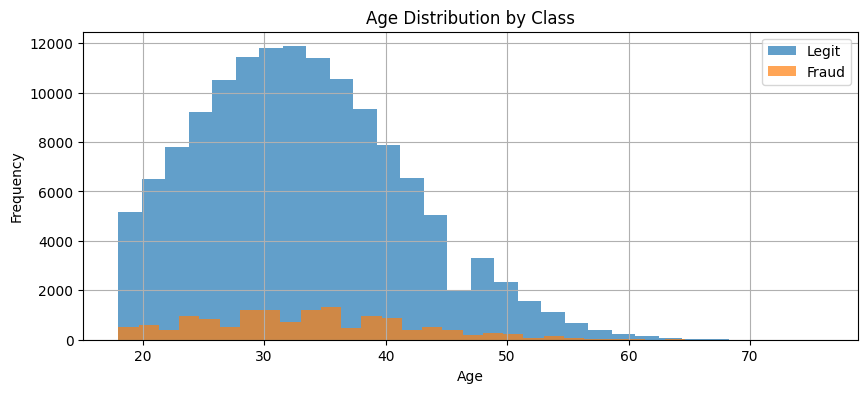

In [18]:
#Age analysis
plt.figure(figsize=(10, 4))
fraud_df[fraud_df['class'] == 0]['age'].hist(bins=30, alpha=0.7, label='Legit')
fraud_df[fraud_df['class'] == 1]['age'].hist(bins=30, alpha=0.7, label='Fraud')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Class')
plt.legend()
plt.savefig('../reports/age_distribution.png', dpi=100)
plt.show()